# Using Data to inform game design changes
<hr>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import requests
import seaborn as sns
from sklearn.linear_model import LinearRegression
import Data_Functions as dh

In [2]:
powerup_df = dh.read_powerup_data()

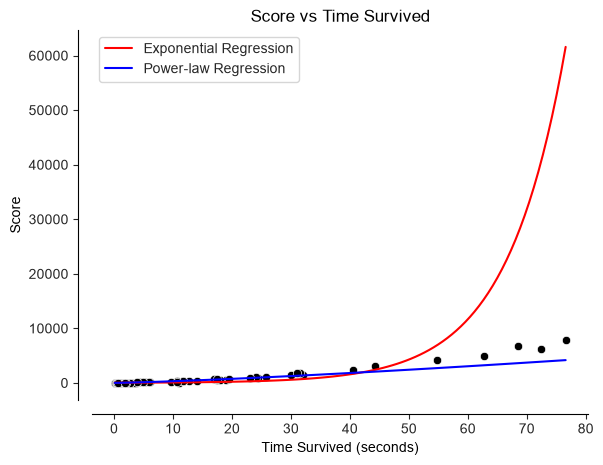

Exponential:   Score = 28.37 * exp(0.100307 * Time Survived)
Exponential R²: 0.758
Power-law:   Score = 15.85 × Time Survived^1.28
Power-law R²:   0.978


In [3]:
gr_df = dh.read_results()

dh.score_over_time(data=gr_df)

In [4]:
merged_df = dh.powerup_gr_merge(powerup_df,gr_df)
merged_df.head()

,Powerup,Time Spawned,Time Activated,Time Effect Ended,Game Version,Time Survived,Score,Survival Group,Score Group,Time Survived After Activated
Date,,,,,,,,,,
2026-08-20 19:53:15.689284,Eat_Enemy_Powerup,22.549473,25.925230,30.938932,2026-08-19 16:09:37.386632,54.742633,4164,30 < 60,1000 < 4999,28.817402
2026-08-20 19:53:15.689284,Eat_Enemy_Powerup,45.070239,45.870412,50.875540,2026-08-19 16:09:37.386632,54.742633,4164,30 < 60,1000 < 4999,8.872221
2026-08-20 19:53:15.689284,Score_Increase_Powerup,15.043289,15.925274,20.856675,2026-08-19 16:09:37.386632,54.742633,4164,30 < 60,1000 < 4999,38.817358
2026-08-20 19:53:15.689284,Score_Increase_Powerup,30.052839,30.883667,35.842999,2026-08-19 16:09:37.386632,54.742633,4164,30 < 60,1000 < 4999,23.858966
2026-08-20 19:53:15.689284,Temp_Change_Colour_Powerup,7.528527,NaN,NaN,2026-08-19 16:09:37.386632,54.742633,4164,30 < 60,1000 < 4999,NaN


## Filtering by Game Version
<hr>
dh.split_game_version can either split a df into a separate df for each game version.<br>
Or it can return a df of a single game version<br>
Or it can return a df of of a list of game versions

In [5]:
dfs, version_map = dh.split_game_version(gr_df.copy())

Single Game Version can be called by what number game version it is or using the datetime itself

In [6]:
new_df = dh.split_game_version(gr_df, 3)
str(new_df.index.dtype)

'datetime64[us]'

List of Game Versions

In [7]:
new_df = dh.split_game_version(gr_df, [1,2])

print(f"Number of Game Results: {len(gr_df)}\nNumber of Game Results (Game Versions 1 and 2): {len(new_df)}")


Number of Game Results: 81
Number of Game Results (Game Versions 1 and 2): 23


## Getting Charts from our new dataframes
<hr>

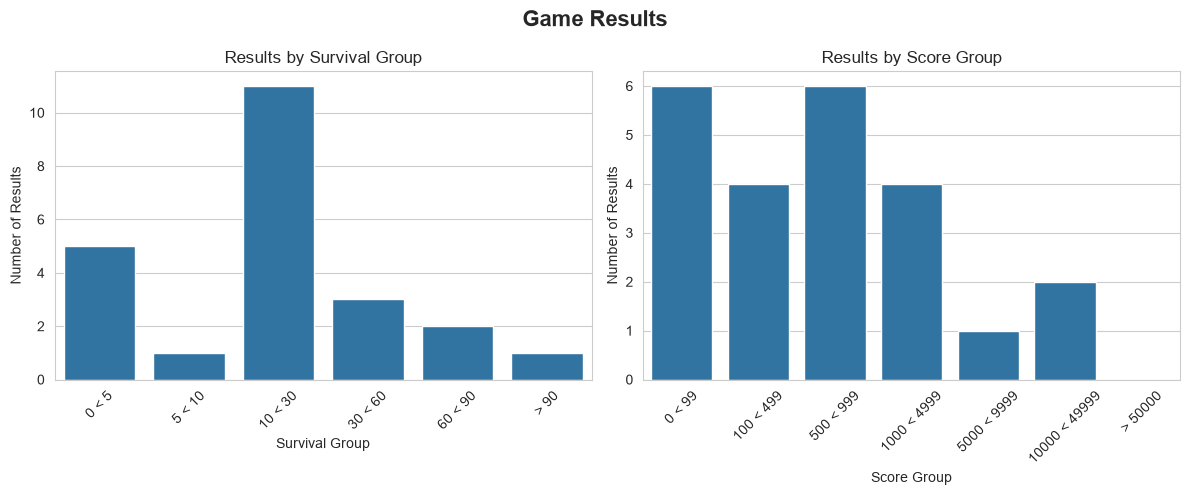

In [8]:
dh.bar_charts(data=new_df)

# Changing how enemies spawn
<hr>


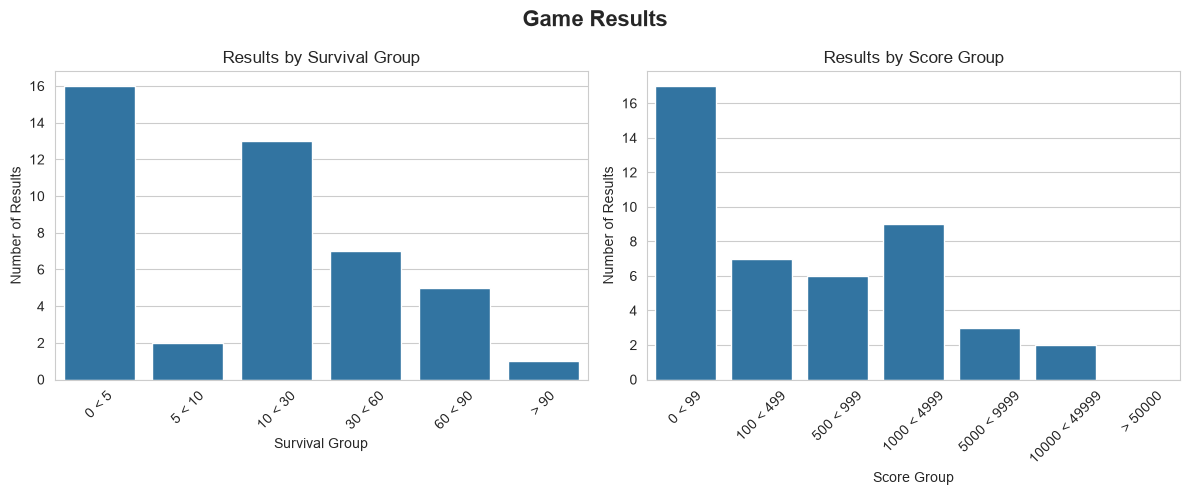

36.36% of games end in the first 5 seconds


In [9]:
early_versions_df = dh.split_game_version(gr_df, [1,2,3])

dh.bar_charts(data=early_versions_df)

quick_end_percent = (len(early_versions_df[early_versions_df["Survival Group"] == "0 < 5"]) / len(early_versions_df))*100

print(f"{quick_end_percent:.2f}% of games end in the first 5 seconds")

From the data above we can see that 36% of games are ending in the first 4 seconds.<br>
This is probably because enemies are spawning too close to the player and heading at them before they have a chance to process what is happening at the start of the game.<br>
We can check this by creating the bar charts again with a group between 0 and 1 seconds.

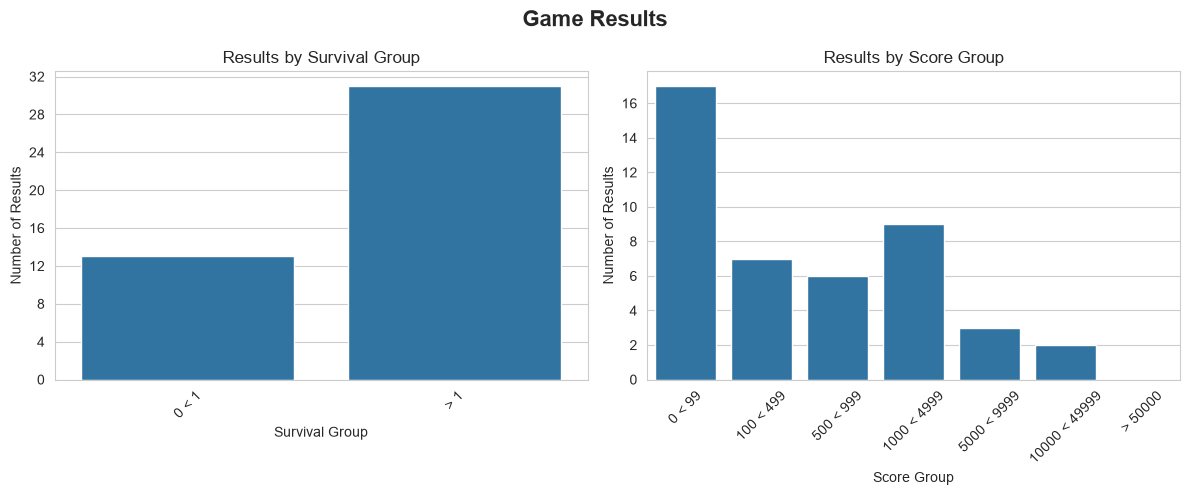

29.55% of games end in the first second


In [10]:
early_versions_df = dh.split_game_version(dh.read_results(time_group=[0, 1, float("inf")]), [1,2,3])

dh.bar_charts(data=early_versions_df)

quick_end_percent = (len(early_versions_df[early_versions_df["Survival Group"] == "0 < 1"]) / len(early_versions_df))*100

print(f"{quick_end_percent:.2f}% of games end in the first second")

Approximately 30% of games end in the first second which shows that players are dying before they are aware the game has started.<br>
To make the game better the logic for spawning an enemy should make enemies not spawn too close to the player.<br>
Also the closest enemies should spawn not heading toward the player to make sure the player does not die by the random chance of an enemy spawning next to the player heading straight at them

## After enemy spawn logic changed
<hr>

### Logic Before Change
<hr>
 def spawn_enemy(self):<br>
&nbsp&nbsp     x = 0<br>
&nbsp&nbsp     while x < 20:<br>
&nbsp&nbsp&nbsp&nbsp         vel = Velocity(angle=random.randint(0,359), speed=random.randint(5,30))<br>
&nbsp&nbsp&nbsp&nbsp         new_enemy = Cube(size=random.randint(10,40), position=dict(x=random.randint(100,self.canvas.winfo_width()-4),y=random.randint(50,self.canvas.winfo_height()-4)), velocity=vel)<br>
&nbsp&nbsp&nbsp&nbsp         if new_enemy.closest_object(self.objects)[1] > 50:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp           self.objects.append(new_enemy)<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp             x + 50<br>
&nbsp&nbsp&nbsp&nbsp         x += 1<br><hr>

This logic just checks that the center of the enemy at least 49 units away from the center of the player.<br>
This is bad because the player is 50 units wide and the enemy can be upto 40 units wide. meaning their edges could be just 5 units away on spawn.<br>
It also does not check if the enemy is heading towards the player as they can have a velocity upto 30 units per frame so could easily hit the player 1 frame after spawning<br>
<br>
### Logic After Change
<hr>
def spawn_enemy(self):<br>
&nbsp&nbsp    x = 0<br>
&nbsp&nbsp    while x < 20:<br>
&nbsp&nbsp&nbsp&nbsp        vel = Velocity(angle=random.randint(0,359), speed=random.randint(5,30))<br>
&nbsp&nbsp&nbsp&nbsp        new_enemy = Cube(size=random.randint(10,40), position=dict(x=random.randint(100,self.canvas.winfo_width()-4),y=random.randint(50,self.canvas.winfo_height()-4)), velocity=vel)<br>
&nbsp&nbsp&nbsp&nbsp        to_player = new_enemy.closest_object(self.objects)<br>
&nbsp&nbsp&nbsp&nbsp        if to_player[1] > 200:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            self.objects.append(new_enemy)<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            x += 50<br>
&nbsp&nbsp&nbsp&nbsp        elif to_player[1] > 100:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            if (0 < new_enemy.velocity.angle < 180) and "Right" not in to_player[2]:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp                x += 50<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            if (180 < new_enemy.velocity.angle < 360) and "Left" not in to_player[2]:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp                x += 50<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            if (90 < new_enemy.velocity.angle < 270) and "Down" not in to_player[2]:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp                x += 50<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp            if (new_enemy.velocity.angle < 90 or 270 < new_enemy.velocity.angle) and "Up" not in to_player[2]:<br>
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp                x += 50<br>
&nbsp&nbsp&nbsp&nbsp        x += 1<br><hr>

The new logic allows enemies to spawn with any heading when over 200 units away.<br>
It also allows enemies to spawn between 100 and 200 units away as long as they are not heading towards the player.<br>
No enemies can spawn within 100 units of the player

## Testing if the new changes have worked
<hr>

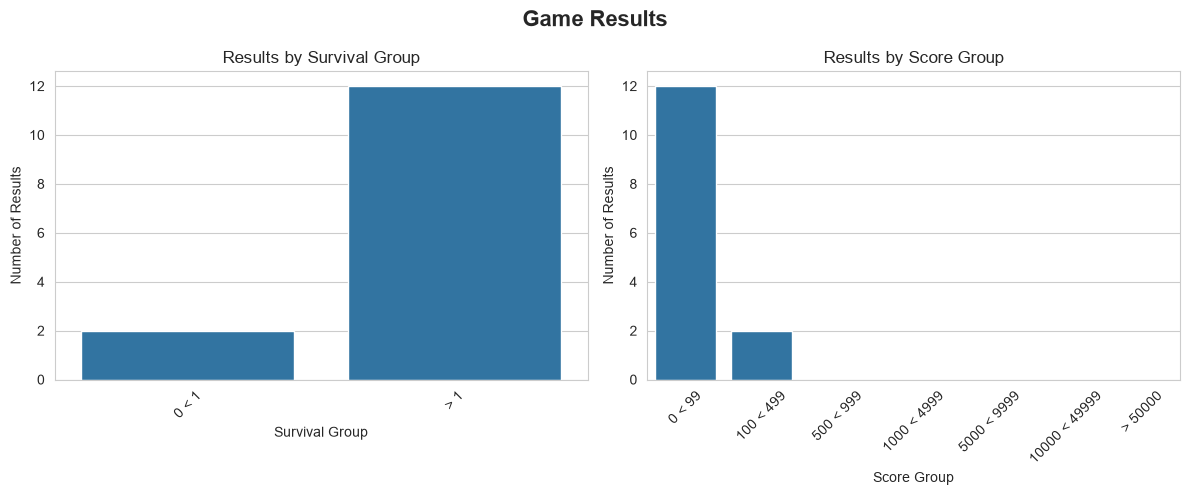

14.29% of games end in the first second


In [11]:
spawn_test_df = dh.split_game_version(dh.read_results(time_group=[0, 1, float("inf")]), 4)

dh.bar_charts(data=spawn_test_df)

quick_end_percent_2 = (len(spawn_test_df[spawn_test_df["Survival Group"] == "0 < 1"]) / len(spawn_test_df))*100

print(f"{quick_end_percent_2:.2f}% of games end in the first second")

The changes made have meant that when not moving at the start of the game only 1 round ended in less than 1 second after 25 games<br>
I consider this change good enough and can move on to other problems

# Eat_Enemy Powerup Bug
<hr>
Whilst playing the game I thought I noticed that I had died colliding with an enemy whilst the Eat Enemy powerup was active.<br>
We can find out if the player has died whilst the effect was active in the data stored.<br>

In [12]:
died_while_active_df = merged_df[(merged_df["Time Activated"].notna() & merged_df["Time Effect Ended"].isna() & (merged_df["Powerup"] == "Eat_Enemy_Powerup"))]
died_while_active_df.head()

,Powerup,Time Spawned,Time Activated,Time Effect Ended,Game Version,Time Survived,Score,Survival Group,Score Group,Time Survived After Activated
Date,,,,,,,,,,
2026-08-20 19:58:06.768919,Eat_Enemy_Powerup,7.525457,13.874352,NaN,2026-08-19 16:09:37.386632,14.077213,386,10 < 30,100 < 499,0.202861
2026-08-20 19:58:50.274679,Eat_Enemy_Powerup,30.052787,30.874717,NaN,2026-08-19 16:09:37.386632,31.090346,1765,30 < 60,1000 < 4999,0.215629
2026-08-22 22:43:03.444771,Eat_Enemy_Powerup,15.019894,16.108155,NaN,2026-08-22 22:38:53.688680,17.453330,683,10 < 30,500 < 999,1.345176


The data above shows that 2 different runs have ended shortly after the powerup was activated.<br>
However there is currently no way of knowing if that was due to hitting an enemy or the border of the window<br>
So now I will need to add a way to record how the player died.<br>
Then I can try and repeat the bug of dying to an enemy while the powerup is active<hr>
The new file game-end-data.csv stores the following data:<br>
`Date` the unique identifier of what run is happening<br>
`Collision Object` What object the player collided with<br>
`Time Spawned` What time during the game if any the `Collision Object` was spawned<br>
`Enemy Count` How many enemies were alive at the time the player died<hr>

In [13]:
ge_df = dh.read_game_end_date()
ge_df.head()

,Collision Object,Time Object Spawned,Enemies Alive
Date,,,
2026-08-22 22:33:57.072173,Cube,1.274048,18
2026-08-22 22:43:03.444771,Cube,0.328647,18
2026-08-22 23:02:02.845476,Cube,0.547126,7
2026-08-22 23:03:31.318706,Border,NaN,19


In [14]:
ee_test_df = dh.split_game_version(dh.read_results(time_group=[0, 1, float("inf")]), 6)

ee_test_df = dh.powerup_gr_merge(powerup_df,ee_test_df)

ee_test_df = ee_test_df[ee_test_df.index.isin(ge_df.index)]

needed_columns = ["Collision Object", "Powerup", "Time Survived After Activated","Game Version"]
ee_test_df = dh.ge_gr_merge(ge_df, ee_test_df, keep_columns=needed_columns)
ee_test_df.head()

,Collision Object,Powerup,Time Survived After Activated,Game Version
Date,,,,
2026-08-22 22:43:03.444771,Cube,Eat_Enemy_Powerup,1.345176,2026-08-22 22:38:53.688680
2026-08-22 22:43:03.444771,Cube,Score_Increase_Powerup,8.095945,2026-08-22 22:38:53.688680


In [16]:
powerup_fails_df = ee_test_df[(ee_test_df["Collision Object"] == "Cube") & (ee_test_df["Powerup"] == "Eat_Enemy_Powerup") & (ee_test_df["Time Survived After Activated"] < 5)]

powerup_fails_df.head()

,Collision Object,Powerup,Time Survived After Activated,Game Version
Date,,,,
2026-08-22 22:43:03.444771,Cube,Eat_Enemy_Powerup,1.345176,2026-08-22 22:38:53.688680


`powerup_fails_df` is not empty and demonstrates that it is possible for the player to die to an enemy whilst the `Eat_Enemy_Powerup` is active which should not be possible